# Categorical Encoding and Imbalanced Classification

**Context:** Guided preprocessing and classification exercises, consolidated and extended for portfolio presentation  
**Tools:** Python, pandas, scikit-learn, imbalanced-learn, Matplotlib, seaborn  
**Methods:** ordinal and one-hot encoding, leakage-safe pipelines, stratified validation,
confusion matrices, oversampling, undersampling, SMOTE

## TL;DR

- The Adult dataset contains **32,561 rows**, including **24 exact duplicates** and
  `?` sentinels in three categorical columns. After deduplication, a leakage-safe mixed-feature
  logistic regression achieves **85.1% accuracy**, **0.900 ROC-AUC**, and **0.762 PR-AUC**
  on a stratified holdout set.
- The Employees example encodes three relevant categorical fields into **14 one-hot features**
  without exposing employee names or discarding rows with missing categories.
- On the Diabetes data, cross-validation selects random oversampling by mean PR-AUC. On the
  untouched test set, minority-class recall rises from **50.7% to 67.2%** and F1 from
  **56.2% to 64.3%**, while precision falls slightly from **63.0% to 61.6%**.
- Resampling is applied only inside the training pipeline. The test distribution remains
  unchanged at **125 negative and 67 positive** observations.

## Context & Methods

This notebook consolidates six guided activities into one reproducible workflow. It answers
three practical questions:

1. How should nominal and genuinely ordinal categories be encoded?
2. How can a confusion matrix reveal errors hidden by overall accuracy?
3. How do resampling strategies affect minority-class performance when evaluated without
   contaminating the test data?

### Key assumptions

- `?` in the Adult data is treated as missing rather than as a genuine category.
- `education.num` duplicates the ordering information in `education`; it is used to derive a
  defensible order and then removed from the model inputs.
- Zero values in selected Diabetes measurements are treated as unavailable measurements and
  median-imputed inside each training fold.
- The positive Diabetes class (`Outcome = 1`) is the minority class of interest.
- Model comparisons prioritise average precision (PR-AUC), which is informative when the
  positive class is less common.

The Adult dataset contains sensitive demographic attributes. This notebook is an educational
encoding demonstration, not a fairness assessment or a system suitable for employment,
lending, or eligibility decisions.

## Setup

Place `adult.csv`, `diabetes.csv`, and `employees.csv` in this project's `data/` folder.
Raw teaching datasets are excluded from GitHub because redistribution permissions have not
been established.

Technical references:

- [scikit-learn: encoding categorical features](https://scikit-learn.org/stable/modules/preprocessing.html#encoding-categorical-features)
- [scikit-learn: pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- [scikit-learn: confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)
- [imbalanced-learn: common pitfalls](https://imbalanced-learn.org/stable/common_pitfalls.html)
- [Scikit-learn MOOC: categorical variables](https://inria.github.io/scikit-learn-mooc/python_scripts/03_categorical_pipeline.html)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
def locate_data_file(filename):
    candidates = [
        Path("data") / filename,
        Path("categorical-encoding-and-imbalanced-classification/data") / filename,
        Path("../categorical-encoding-and-imbalanced-classification/data") / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename!r}. Add it to the project's data/ folder."
    )


adult_raw = pd.read_csv(locate_data_file("adult.csv"))
diabetes = pd.read_csv(locate_data_file("diabetes.csv"))
employees = pd.read_csv(locate_data_file("employees.csv"))

## Data

In [3]:
data_profile = pd.DataFrame(
    {
        "rows": [len(adult_raw), len(diabetes), len(employees)],
        "columns": [adult_raw.shape[1], diabetes.shape[1], employees.shape[1]],
        "encoded_missing_cells": [
            int(adult_raw.isna().sum().sum()),
            int(diabetes.isna().sum().sum()),
            int(employees.isna().sum().sum()),
        ],
        "exact_duplicates": [
            int(adult_raw.duplicated().sum()),
            int(diabetes.duplicated().sum()),
            int(employees.duplicated().sum()),
        ],
    },
    index=["Adult", "Diabetes", "Employees"],
)
data_profile

,rows,columns,encoded_missing_cells,exact_duplicates
Adult,32561,15,0,24
Diabetes,768,9,0,0
Employees,1000,8,322,0


In [4]:
expected_adult_columns = {
    "age", "workclass", "fnlwgt", "education", "education.num",
    "marital.status", "occupation", "relationship", "race", "sex",
    "capital.gain", "capital.loss", "hours.per.week", "native.country", "income"
}
expected_diabetes_columns = {
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
    "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
}
expected_employee_columns = {
    "First Name", "Gender", "Start Date", "Last Login Time", "Salary",
    "Bonus %", "Senior Management", "Team"
}

assert set(adult_raw.columns) == expected_adult_columns
assert set(diabetes.columns) == expected_diabetes_columns
assert set(employees.columns) == expected_employee_columns
assert set(diabetes["Outcome"].unique()) == {0, 1}
print("Schemas validated.")

Schemas validated.


## Results

### 1. Adult data: distinguish missing, ordinal, and nominal categories

In [5]:
adult_question_marks = pd.Series(
    {
        column: int(adult_raw[column].eq("?").sum())
        for column in adult_raw.select_dtypes(include="object").columns
        if adult_raw[column].eq("?").any()
    },
    name="question_mark_count",
)
adult_question_marks.to_frame()

,question_mark_count
workclass,1836
occupation,1843
native.country,583


In [6]:
adult = adult_raw.drop_duplicates().replace("?", np.nan).copy()
adult_target = adult.pop("income").map({"<=50K": 0, ">50K": 1})

education_order = (
    adult[["education", "education.num"]]
    .drop_duplicates()
    .sort_values("education.num")["education"]
    .tolist()
)
adult_features = adult.drop(columns="education.num")

adult_summary = pd.Series(
    {
        "rows_before": len(adult_raw),
        "exact_duplicates_removed": int(adult_raw.duplicated().sum()),
        "rows_after": len(adult_features),
        "positive_class_pct": 100 * adult_target.mean(),
        "education_levels": len(education_order),
    },
    name="value",
)
adult_summary.round(2).to_frame()

,value
rows_before,32561.00
exact_duplicates_removed,24.00
rows_after,32537.00
positive_class_pct,24.09
education_levels,16.00


In [7]:
adult_ordinal_columns = ["education"]
adult_nominal_columns = [
    column
    for column in adult_features.select_dtypes(include="object").columns
    if column not in adult_ordinal_columns
]
adult_numeric_columns = adult_features.select_dtypes(exclude="object").columns.tolist()

adult_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            adult_numeric_columns,
        ),
        (
            "education",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "ordinal",
                        OrdinalEncoder(
                            categories=[education_order],
                            handle_unknown="use_encoded_value",
                            unknown_value=-1,
                        ),
                    ),
                    ("scaler", StandardScaler()),
                ]
            ),
            adult_ordinal_columns,
        ),
        (
            "nominal",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            adult_nominal_columns,
        ),
    ]
)

adult_X_train, adult_X_test, adult_y_train, adult_y_test = train_test_split(
    adult_features,
    adult_target,
    test_size=0.20,
    stratify=adult_target,
    random_state=RANDOM_STATE,
)

adult_model = Pipeline(
    [
        ("preprocessor", adult_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                solver="liblinear",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)
adult_model.fit(adult_X_train, adult_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','workclass','fnlwgt',...,'capital.loss','hours.per.week', 'native.country']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('education', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [8]:
adult_feature_names = adult_model.named_steps["preprocessor"].get_feature_names_out()
transformed_preview = adult_model.named_steps["preprocessor"].transform(
    adult_X_train.head(5)
)
if hasattr(transformed_preview, "toarray"):
    transformed_preview = transformed_preview.toarray()

pd.DataFrame(
    transformed_preview[:, :12],
    columns=adult_feature_names[:12],
    index=adult_X_train.head(5).index,
).round(3)

,numeric__age,numeric__fnlwgt,numeric__capital.gain,numeric__capital.loss,numeric__hours.per.week,education__education,nominal__workclass_Federal-gov,nominal__workclass_Local-gov,nominal__workclass_Never-worked,nominal__workclass_Private,nominal__workclass_Self-emp-inc,nominal__workclass_Self-emp-not-inc
25267,-1.285,-0.471,-0.147,-0.218,-1.663,-0.031,0.0,0.0,0.0,1.0,0.0,0.0
3349,0.183,2.307,0.441,-0.218,1.592,0.358,0.0,0.0,0.0,1.0,0.0,0.0
4584,-1.065,0.492,-0.147,-0.218,-0.036,-0.420,0.0,0.0,0.0,1.0,0.0,0.0
7003,1.505,-0.857,-0.147,-0.218,-1.826,-0.420,0.0,0.0,0.0,1.0,0.0,0.0
882,-0.257,0.737,-0.147,4.423,0.778,-0.420,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
def binary_metrics(y_true, y_pred, y_probability):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_probability),
        "average_precision": average_precision_score(y_true, y_probability),
    }


adult_predictions = adult_model.predict(adult_X_test)
adult_probabilities = adult_model.predict_proba(adult_X_test)[:, 1]
adult_metrics = pd.Series(
    binary_metrics(adult_y_test, adult_predictions, adult_probabilities),
    name="Adult holdout",
)
adult_metrics.round(4).to_frame()

,Adult holdout
accuracy,0.8510
balanced_accuracy,0.7638
precision,0.7354
recall,0.5957
f1,0.6582
roc_auc,0.9002
average_precision,0.7623


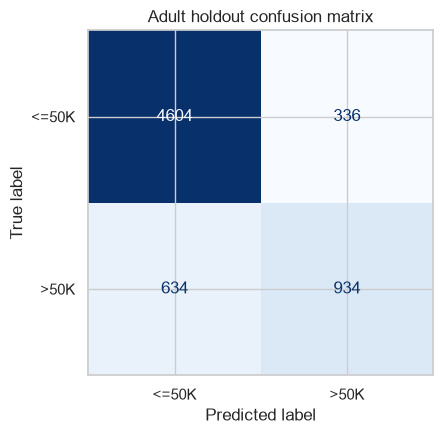

In [10]:
fig, axis = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    adult_y_test,
    adult_predictions,
    display_labels=["<=50K", ">50K"],
    cmap="Blues",
    colorbar=False,
    ax=axis,
)
axis.set_title("Adult holdout confusion matrix")
plt.tight_layout()
plt.show()

The mixed-feature pipeline produces 88 model inputs. The holdout accuracy is 85.1%, but
balanced accuracy is lower at 76.4% and recall for the higher-income class is 59.6%.
The confusion matrix makes this asymmetry visible; accuracy alone would hide it.

### 2. Employees data: encode useful categories without exposing names

In [11]:
employee_categorical_columns = ["Gender", "Senior Management", "Team"]
employee_categories = employees[employee_categorical_columns].copy()

# Convert observed values to consistent strings while preserving missing values.
for column in employee_categorical_columns:
    employee_categories[column] = employee_categories[column].map(
        lambda value: str(value) if pd.notna(value) else value
    )

employee_encoder = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ),
    ]
)
employee_encoded_array = employee_encoder.fit_transform(employee_categories)
employee_feature_names = employee_encoder.named_steps["onehot"].get_feature_names_out(
    employee_categorical_columns
)
employee_encoded = pd.DataFrame(
    employee_encoded_array,
    columns=employee_feature_names,
    index=employees.index,
)

employee_encoding_summary = pd.DataFrame(
    {
        "missing_before": employee_categories.isna().sum(),
        "observed_categories": employee_categories.nunique(dropna=True),
    }
)
employee_encoding_summary.loc["encoded_output", "observed_categories"] = employee_encoded.shape[1]
employee_encoding_summary

,missing_before,observed_categories
Gender,145.0,2.0
Senior Management,67.0,2.0
Team,43.0,10.0
encoded_output,NaN,14.0


In [12]:
employee_encoded.head().astype(int)

,Gender_Female,Gender_Male,Senior Management_False,Senior Management_True,Team_Business Development,Team_Client Services,Team_Distribution,Team_Engineering,Team_Finance,Team_Human Resources,Team_Legal,Team_Marketing,Team_Product,Team_Sales
0,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,0,1,0,1,0,1,0,0,0,0,0,0,0,0
2,1,0,1,0,0,0,0,0,1,0,0,0,0,0
3,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,1,0,1,0,1,0,0,0,0,0,0,0,0


`First Name`, `Start Date`, and `Last Login Time` are excluded because they are identifiers or
require separate temporal feature engineering. Missing categories are imputed inside the
encoder, so all 1,000 rows remain available and employee names never enter the encoded output.

### 3. Diabetes data: evaluate resampling without test leakage

In [13]:
diabetes_X = diabetes.drop(columns="Outcome").copy()
diabetes_y = diabetes["Outcome"].copy()
zero_as_missing_columns = [
    "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"
]
diabetes_X[zero_as_missing_columns] = diabetes_X[zero_as_missing_columns].replace(
    0, np.nan
)

diabetes_X_train, diabetes_X_test, diabetes_y_train, diabetes_y_test = train_test_split(
    diabetes_X,
    diabetes_y,
    test_size=0.25,
    stratify=diabetes_y,
    random_state=RANDOM_STATE,
)

class_distribution = pd.DataFrame(
    {
        "full": diabetes_y.value_counts().sort_index(),
        "train": diabetes_y_train.value_counts().sort_index(),
        "test": diabetes_y_test.value_counts().sort_index(),
    }
)
class_distribution.index = ["No diabetes", "Diabetes"]
class_distribution

,full,train,test
No diabetes,500,375,125
Diabetes,268,201,67


In [14]:
sampler_options = {
    "Baseline": "passthrough",
    "Random oversampling": RandomOverSampler(random_state=RANDOM_STATE),
    "Random undersampling": RandomUnderSampler(random_state=RANDOM_STATE),
    "SMOTE": SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
}

def make_diabetes_pipeline(sampler):
    return ImbPipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("sampler", sampler),
            (
                "model",
                LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
            ),
        ]
    )


scoring = [
    "accuracy", "balanced_accuracy", "precision", "recall", "f1",
    "roc_auc", "average_precision"
]
cross_validator = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=RANDOM_STATE
)

comparison_rows = []
for strategy_name, sampler in sampler_options.items():
    scores = cross_validate(
        make_diabetes_pipeline(sampler),
        diabetes_X_train,
        diabetes_y_train,
        cv=cross_validator,
        scoring=scoring,
        n_jobs=1,
    )
    row = {"strategy": strategy_name}
    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    comparison_rows.append(row)

diabetes_cv_results = (
    pd.DataFrame(comparison_rows)
    .set_index("strategy")
    .sort_values("average_precision_mean", ascending=False)
)
diabetes_cv_results.round(4)

,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
strategy,,,,,,,,,,,,,,
Random oversampling,0.7622,0.0226,0.7484,0.0261,0.6494,0.0377,0.7021,0.0632,0.6725,0.0340,0.8347,0.0174,0.7265,0.0347
SMOTE,0.7570,0.0205,0.7444,0.0301,0.6382,0.0228,0.7021,0.0707,0.6670,0.0383,0.8332,0.0206,0.7231,0.0422
Baseline,0.7779,0.0247,0.7326,0.0291,0.7277,0.0442,0.5826,0.0533,0.6460,0.0434,0.8305,0.0228,0.7183,0.0417
Random undersampling,0.7570,0.0190,0.7512,0.0270,0.6304,0.0163,0.7317,0.0556,0.6768,0.0322,0.8262,0.0290,0.7146,0.0522


In [15]:
selected_strategy = diabetes_cv_results["average_precision_mean"].idxmax()

fitted_diabetes_models = {}
test_rows = []
for strategy_name in ["Baseline", selected_strategy]:
    fitted_pipeline = make_diabetes_pipeline(sampler_options[strategy_name])
    fitted_pipeline.fit(diabetes_X_train, diabetes_y_train)
    predictions = fitted_pipeline.predict(diabetes_X_test)
    probabilities = fitted_pipeline.predict_proba(diabetes_X_test)[:, 1]
    fitted_diabetes_models[strategy_name] = {
        "pipeline": fitted_pipeline,
        "predictions": predictions,
        "probabilities": probabilities,
    }
    test_rows.append(
        {
            "strategy": strategy_name,
            **binary_metrics(diabetes_y_test, predictions, probabilities),
        }
    )

diabetes_test_results = pd.DataFrame(test_rows).set_index("strategy")
print(f"Selected by cross-validated PR-AUC: {selected_strategy}")
diabetes_test_results.round(4)

Selected by cross-validated PR-AUC: Random oversampling


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
strategy,,,,,,,
Baseline,0.7240,0.6737,0.6296,0.5075,0.5620,0.8239,0.6960
Random oversampling,0.7396,0.7238,0.6164,0.6716,0.6429,0.8254,0.7023


In [16]:
selected_sampler = fitted_diabetes_models[selected_strategy]["pipeline"].named_steps[
    "sampler"
]
sampled_target = diabetes_y_train.iloc[selected_sampler.sample_indices_]
sampling_counts = pd.DataFrame(
    {
        "training_before": diabetes_y_train.value_counts().sort_index(),
        "training_after_selected_resampling": sampled_target.value_counts().sort_index(),
        "test_untouched": diabetes_y_test.value_counts().sort_index(),
    }
)
sampling_counts.index = ["No diabetes", "Diabetes"]
sampling_counts

,training_before,training_after_selected_resampling,test_untouched
No diabetes,375,375,125
Diabetes,201,375,67


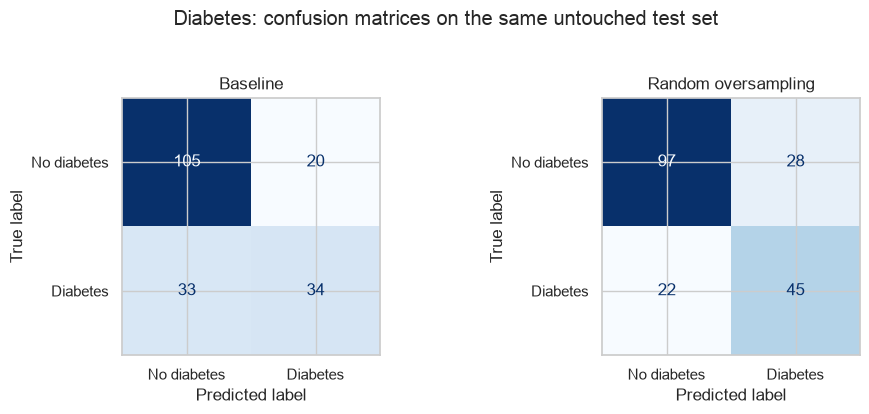

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, strategy_name in zip(axes, ["Baseline", selected_strategy]):
    ConfusionMatrixDisplay.from_predictions(
        diabetes_y_test,
        fitted_diabetes_models[strategy_name]["predictions"],
        display_labels=["No diabetes", "Diabetes"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(strategy_name)
fig.suptitle("Diabetes: confusion matrices on the same untouched test set", y=1.03)
plt.tight_layout()
plt.show()

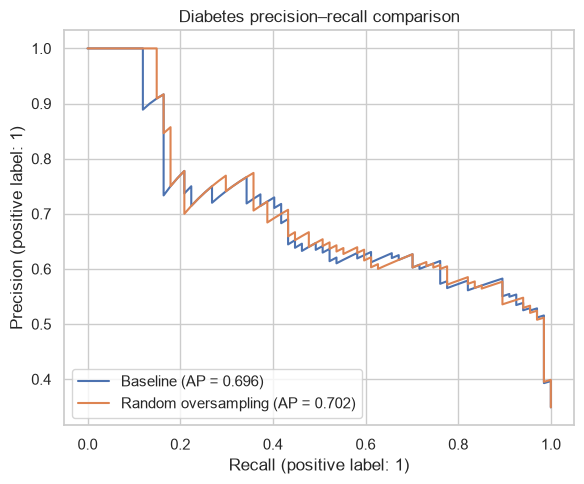

In [18]:
fig, axis = plt.subplots(figsize=(6, 5))
for strategy_name in ["Baseline", selected_strategy]:
    probabilities = fitted_diabetes_models[strategy_name]["probabilities"]
    precision, recall, _ = precision_recall_curve(diabetes_y_test, probabilities)
    average_precision = average_precision_score(diabetes_y_test, probabilities)
    axis.plot(
        recall,
        precision,
        label=f"{strategy_name} (AP = {average_precision:.3f})",
    )
axis.set_xlabel("Recall (positive label: 1)")
axis.set_ylabel("Precision (positive label: 1)")
axis.set_title("Diabetes precision–recall comparison")
axis.legend(loc="lower left")
plt.tight_layout()
plt.show()

Random oversampling is selected from training-fold PR-AUC, not from the test set. On the
untouched holdout set it identifies 45 of 67 positive cases, compared with 34 for the
baseline. The trade-off is 28 false positives instead of 20. Whether that trade-off is
desirable depends on the real cost of missed cases versus unnecessary follow-up.

## Checks

In [19]:
assert len(adult_raw) == 32561
assert int(adult_raw.duplicated().sum()) == 24
assert len(adult_features) == 32537
assert len(adult_feature_names) == 88
assert confusion_matrix(adult_y_test, adult_predictions).sum() == len(adult_y_test)

assert employee_encoded.shape == (1000, 14)
assert not employee_encoded.isna().any().any()
assert not any("First Name" in name for name in employee_feature_names)

assert set(diabetes_X_train.index).isdisjoint(diabetes_X_test.index)
assert diabetes_y_test.value_counts().sort_index().to_dict() == {0: 125, 1: 67}
assert selected_strategy == "Random oversampling"
assert set(diabetes_cv_results.index) == set(sampler_options)
assert all(
    confusion_matrix(
        diabetes_y_test,
        fitted_diabetes_models[name]["predictions"],
    ).sum() == len(diabetes_y_test)
    for name in ["Baseline", selected_strategy]
)
assert (
    diabetes_test_results.loc[selected_strategy, "recall"]
    > diabetes_test_results.loc["Baseline", "recall"]
)
assert (
    diabetes_test_results.loc[selected_strategy, "f1"]
    > diabetes_test_results.loc["Baseline", "f1"]
)

print("All validation checks passed.")

All validation checks passed.


## Takeaways

- Encoding should reflect meaning: `education` has a defensible order, while categories such
  as occupation or team should not be assigned an artificial ranking.
- `handle_unknown="ignore"` allows pipelines to process categories that were absent during fit.
- Missing-value treatment, encoding, scaling, and resampling belong inside training pipelines
  so validation and test data remain unseen during fitting.
- Accuracy is insufficient for imbalanced outcomes. Confusion matrices, recall, F1, ROC-AUC,
  and PR-AUC expose different trade-offs.
- Oversampling improved recall and F1 in this split but did not eliminate uncertainty. Final
  method and threshold choices require domain costs, calibration, fairness checks, and external
  validation.